In [1]:
!pip install yfinance
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


Live data downloaded for 10 stocks
Price             Close         High          Low         Open      Volume
Ticker      RELIANCE.NS  RELIANCE.NS  RELIANCE.NS  RELIANCE.NS RELIANCE.NS
Date                                                                      
2026-05-07  1436.199951  1449.500000  1430.300049  1438.800049    19816903
2026-05-08  1435.199951  1442.800049  1417.500000  1426.000000     8663105
2026-05-11  1388.199951  1428.000000  1382.000000  1420.000000    15255792
      Stock    Price     MA20     MA50    RSI  Volatility  Return%
0  Reliance  1388.20  1389.17  1383.72  56.86        1.70    -3.27
1       TCS  2392.90  2481.53  2485.14  22.47        1.78    -0.06
2   Infosys  1177.00  1219.78  1258.31  25.63        2.06    -0.19
3      HDFC   763.65   787.99   807.36  30.43        1.49    -2.20
4     Wipro   196.68   202.06   198.73  30.18        1.41    -0.62
5      ONGC   281.00   287.93   280.63  47.96        1.69     0.64
6       ITC   305.85   307.31   305.23  44.40 

/tmp/ipykernel_1246/2357146301.py:47: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_price = round(float(close.iloc[-1]), 2)
/tmp/ipykernel_1246/2357146301.py:48: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_ma20  = round(float(ma20.iloc[-1]), 2)
/tmp/ipykernel_1246/2357146301.py:49: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_ma50  = round(float(ma50.iloc[-1]), 2)
/tmp/ipykernel_1246/2357146301.py:50: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  latest_rsi   = round(float(rsi.iloc[-1]), 2)
/tmp/ipykernel_1246/2357146301.py:51: FutureWarning: Calling float on a single eleme

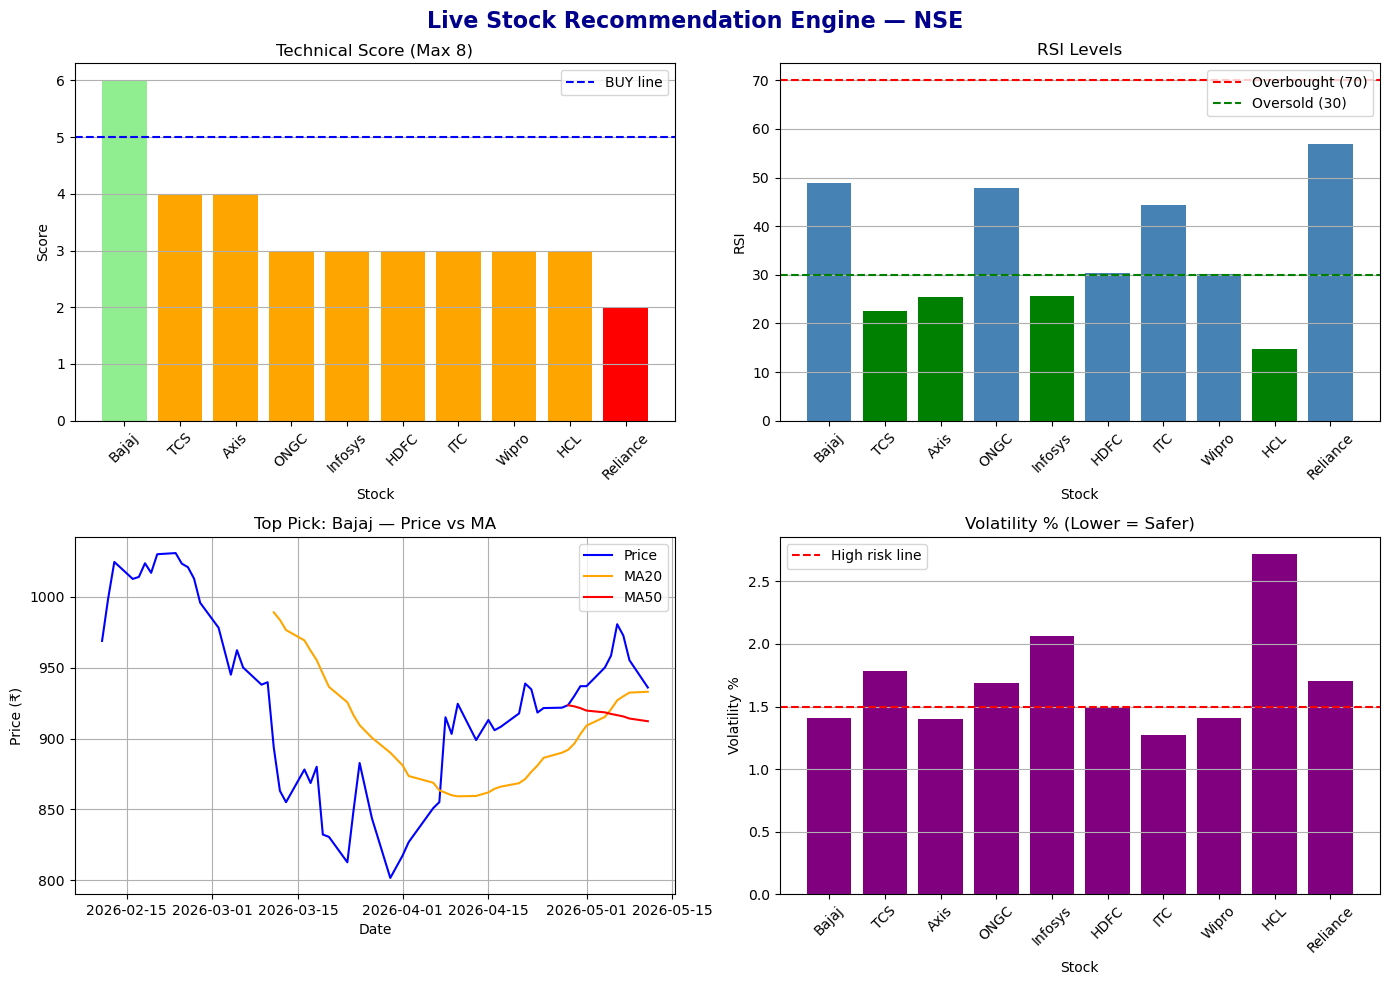

     LIVE STOCK RECOMMENDATION ENGINE — NSE INDIA
     Generated: 11 May 2026 18:15

📈 Bajaj
   Price: ₹936.05 | RSI: 48.9 | Volatility: 1.41%
   Score: 6/8 → BUY
   Why: Strong uptrend | Neutral momentum | Medium risk

🟡 TCS
   Price: ₹2392.9 | RSI: 22.47 | Volatility: 1.78%
   Score: 4/8 → HOLD
   Why: Downtrend | Oversold — buy opportunity | Medium risk

🟡 Axis
   Price: ₹1272.3 | RSI: 25.44 | Volatility: 1.4%
   Score: 4/8 → HOLD
   Why: Downtrend | Oversold — buy opportunity | Medium risk

🟡 ONGC
   Price: ₹281.0 | RSI: 47.96 | Volatility: 1.69%
   Score: 3/8 → HOLD
   Why: Downtrend | Neutral momentum | Medium risk

🟡 Infosys
   Price: ₹1177.0 | RSI: 25.63 | Volatility: 2.06%
   Score: 3/8 → HOLD
   Why: Downtrend | Oversold — buy opportunity | High volatility — risky

🟡 HDFC
   Price: ₹763.65 | RSI: 30.43 | Volatility: 1.49%
   Score: 3/8 → HOLD
   Why: Downtrend | Neutral momentum | Medium risk

🟡 ITC
   Price: ₹305.85 | RSI: 44.4 | Volatility: 1.27%
   Score: 3/8 → HOLD
   Why

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
tickers = [
    "RELIANCE.NS", "TCS.NS", "INFY.NS",
    "HDFCBANK.NS", "WIPRO.NS", "ONGC.NS",
    "ITC.NS", "BAJFINANCE.NS", "AXISBANK.NS", "HCLTECH.NS"
]

names = ["Reliance","TCS","Infosys","HDFC",
         "Wipro","ONGC","ITC","Bajaj","Axis","HCL"]

# download 6 months of data
raw_data = {}
for ticker, name in zip(tickers, names):
    df = yf.download(ticker, period="6mo", progress=False)
    raw_data[name] = df

print("Live data downloaded for", len(raw_data), "stocks")
print(raw_data["Reliance"].tail(3))
def calculate_rsi(prices, period=14):
    delta = prices.diff()
    gain  = delta.where(delta > 0, 0).rolling(period).mean()
    loss  = (-delta.where(delta < 0, 0)).rolling(period).mean()
    rs    = gain / loss
    rsi   = 100 - (100 / (1 + rs))
    return rsi

results = []

for name, df in raw_data.items():
    close = df["Close"]

    # moving averages
    ma20 = close.rolling(20).mean()
    ma50 = close.rolling(50).mean()

    # RSI
    rsi = calculate_rsi(close)

    # volatility
    returns    = close.pct_change() * 100
    volatility = returns.rolling(20).std()

    # get latest values
    latest_price = round(float(close.iloc[-1]), 2)
    latest_ma20  = round(float(ma20.iloc[-1]), 2)
    latest_ma50  = round(float(ma50.iloc[-1]), 2)
    latest_rsi   = round(float(rsi.iloc[-1]), 2)
    latest_vol   = round(float(volatility.iloc[-1]), 2)
    daily_return = round(float(returns.iloc[-1]), 2)

    results.append({
        "Stock":      name,
        "Price":      latest_price,
        "MA20":       latest_ma20,
        "MA50":       latest_ma50,
        "RSI":        latest_rsi,
        "Volatility": latest_vol,
        "Return%":    daily_return
    })

df_result = pd.DataFrame(results)
print(df_result)
def technical_score(row):
    score = 0
    reasons = []

    # MA signal — price vs moving averages
    if row["Price"] > row["MA20"] > row["MA50"]:
        score += 3
        reasons.append("Strong uptrend")
    elif row["Price"] > row["MA20"]:
        score += 2
        reasons.append("Short term uptrend")
    else:
        score += 0
        reasons.append("Downtrend")

    # RSI signal
    if row["RSI"] < 30:
        score += 3
        reasons.append("Oversold — buy opportunity")
    elif row["RSI"] < 50:
        score += 2
        reasons.append("Neutral momentum")
    elif row["RSI"] < 70:
        score += 1
        reasons.append("Positive momentum")
    else:
        score += 0
        reasons.append("Overbought — risky")

    # Volatility signal
    if row["Volatility"] < 1:
        score += 2
        reasons.append("Low risk")
    elif row["Volatility"] < 2:
        score += 1
        reasons.append("Medium risk")
    else:
        score += 0
        reasons.append("High volatility — risky")

    return score, " | ".join(reasons)

scores   = []
reasons  = []

for _, row in df_result.iterrows():
    s, r = technical_score(row)
    scores.append(s)
    reasons.append(r)

df_result["Score"]   = scores
df_result["Reasons"] = reasons

# final recommendation
def recommend(score):
    if score >= 7:
        return "STRONG BUY"
    elif score >= 5:
        return "BUY"
    elif score >= 3:
        return "HOLD"
    else:
        return "AVOID"

df_result["Recommendation"] = df_result["Score"].apply(recommend)

# sort by score
df_result = df_result.sort_values("Score",
            ascending=False).reset_index(drop=True)

print("\nRecommendations:")
print(df_result[["Stock","Price","RSI",
                  "Score","Recommendation"]])
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Live Stock Recommendation Engine — NSE",
             fontsize=16, fontweight="bold", color="darkblue")

# Chart 1 — Recommendation scores
colors = ["green"  if r == "STRONG BUY" else
          "lightgreen" if r == "BUY" else
          "orange" if r == "HOLD" else
          "red" for r in df_result["Recommendation"]]
axes[0,0].bar(df_result["Stock"], df_result["Score"],
              color=colors)
axes[0,0].set_title("Technical Score (Max 8)")
axes[0,0].set_xlabel("Stock")
axes[0,0].set_ylabel("Score")
axes[0,0].axhline(y=5, color="blue", linestyle="--",
                   label="BUY line")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].legend()
axes[0,0].grid(axis="y")

# Chart 2 — RSI levels
rsi_colors = ["green" if r < 30 else
              "red"   if r > 70 else
              "steelblue" for r in df_result["RSI"]]
axes[0,1].bar(df_result["Stock"], df_result["RSI"],
              color=rsi_colors)
axes[0,1].axhline(y=70, color="red",    linestyle="--",
                   label="Overbought (70)")
axes[0,1].axhline(y=30, color="green",  linestyle="--",
                   label="Oversold (30)")
axes[0,1].set_title("RSI Levels")
axes[0,1].set_xlabel("Stock")
axes[0,1].set_ylabel("RSI")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].legend()
axes[0,1].grid(axis="y")

# Chart 3 — Price vs MA20 vs MA50 for top pick
top_stock  = df_result["Stock"].iloc[0]
top_ticker = tickers[names.index(top_stock)]
hist = yf.download(top_ticker, period="3mo", progress=False)

axes[1,0].plot(hist.index, hist["Close"],
               label="Price", color="blue")
axes[1,0].plot(hist.index,
               hist["Close"].rolling(20).mean(),
               label="MA20", color="orange")
axes[1,0].plot(hist.index,
               hist["Close"].rolling(50).mean(),
               label="MA50", color="red")
axes[1,0].set_title(f"Top Pick: {top_stock} — Price vs MA")
axes[1,0].set_xlabel("Date")
axes[1,0].set_ylabel("Price (₹)")
axes[1,0].legend()
axes[1,0].grid(True)

# Chart 4 — Volatility
axes[1,1].bar(df_result["Stock"], df_result["Volatility"],
              color="purple")
axes[1,1].set_title("Volatility % (Lower = Safer)")
axes[1,1].set_xlabel("Stock")
axes[1,1].set_ylabel("Volatility %")
axes[1,1].axhline(y=1.5, color="red", linestyle="--",
                   label="High risk line")
axes[1,1].tick_params(axis="x", rotation=45)
axes[1,1].legend()
axes[1,1].grid(axis="y")

plt.tight_layout()
plt.savefig("stock_recommender.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("=" * 65)
print("     LIVE STOCK RECOMMENDATION ENGINE — NSE INDIA")
print("     Generated:", pd.Timestamp.now().strftime("%d %b %Y %H:%M"))
print("=" * 65)

for _, row in df_result.iterrows():
    icon = ("🟢" if row["Recommendation"] == "STRONG BUY" else
            "📈" if row["Recommendation"] == "BUY" else
            "🟡" if row["Recommendation"] == "HOLD" else "🔴")

    print(f"\n{icon} {row['Stock']}")
    print(f"   Price: ₹{row['Price']} | RSI: {row['RSI']} | "
          f"Volatility: {row['Volatility']}%")
    print(f"   Score: {row['Score']}/8 → {row['Recommendation']}")
    print(f"   Why: {row['Reasons']}")

print("\n" + "=" * 65)
print("TOP 3 PICKS TODAY:")
for i, row in df_result.head(3).iterrows():
    print(f"  {i+1}. {row['Stock']} — "
          f"{row['Recommendation']} (Score: {row['Score']}/8)")
print("=" * 65)